> Part of **Complete Machine Learning Study Material** — split across per-chapter notebooks. See [`00_index.ipynb`](00_index.ipynb) for the notebook conventions, the per-concept template, the chapter coverage tracker and the cross-reference index.

## 12. Regularized Linear Models

*Scope:* Ridge, lasso and elastic net — the same linear model with a penalty term, and what that term does to the coefficients.

Chapter 11 ended with two unresolved problems. When $p > n$ the normal equation returns an arbitrary exact
interpolation of noise (11.3.2), and when features are collinear the coefficients become unstable enough
that no claim about them survives a bootstrap (11.7).

Both have the same cure: add a penalty on the size of the coefficients. The model family, the data and the
loss are unchanged — only the objective gains a second term.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score, train_test_split

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.width", 115)
sns.set_theme(style="whitegrid")

cv = KFold(5, shuffle=True, random_state=RANDOM_STATE)
print("ready")

ready


### 12.1 Why Regularize a Linear Model

9.6 gave the general form: minimize the loss **plus** a penalty on the parameters.

$$J(\mathbf{w}) = \underbrace{\frac{1}{n}\lVert X\mathbf{w} - y \rVert^2}_{\text{fit the data}} \;+\; \underbrace{\lambda\,\Omega(\mathbf{w})}_{\text{stay small}}$$

| $\Omega(\mathbf{w})$ | Name | scikit-learn | Effect |
|---|---|---|---|
| $\sum_j w_j^2 = \lVert \mathbf{w} \rVert_2^2$ | **Ridge** (L2) | `Ridge(alpha=λ)` | Shrinks every coefficient smoothly |
| $\sum_j \lvert w_j \rvert = \lVert \mathbf{w} \rVert_1$ | **Lasso** (L1) | `Lasso(alpha=λ)` | Shrinks, and sets some to **exactly zero** |
| A mix of both | **Elastic net** | `ElasticNet(alpha, l1_ratio)` | Shrinks and selects |

Those are 2.3's norms applied to the coefficient vector. The penalty is on $\mathbf{w}$ only — **never on
the intercept**, which merely sets the overall level and carries no complexity.

The motivating case is the regime 11.3.2 left hanging: **more features than the data can support, most of
them irrelevant.** Sixty rows, a hundred features, and only five that matter.

In [2]:
n_hard, p_hard = 60, 100
X_hard = rng.normal(size=(n_hard, p_hard))
w_hard = np.zeros(p_hard)
w_hard[:5] = [4.0, -3.0, 2.5, 2.0, -1.5]           # only 5 of 100 features carry signal
y_hard = X_hard @ w_hard + rng.normal(0, 1.0, n_hard)

X_h_tr, X_h_te, y_h_tr, y_h_te = train_test_split(X_hard, y_hard, test_size=0.4,
                                                  random_state=RANDOM_STATE)
print(f"training rows {len(X_h_tr)}, features {p_hard}, truly relevant 5")

training rows 36, features 100, truly relevant 5


In [3]:
ols = LinearRegression().fit(X_h_tr, y_h_tr)
ridge = Ridge(alpha=1.0).fit(X_h_tr, y_h_tr)
lasso = Lasso(alpha=0.5, max_iter=20_000).fit(X_h_tr, y_h_tr)

for name, m in (("OLS", ols), ("ridge (alpha=1)", ridge), ("lasso (alpha=0.5)", lasso)):
    nonzero = int((np.abs(m.coef_) > 1e-10).sum())
    print(f"{name:<19} train R^2 {m.score(X_h_tr, y_h_tr):>8.4f}"
          f"   TEST R^2 {m.score(X_h_te, y_h_te):>8.4f}   non-zero coefficients {nonzero:>3}")

OLS                 train R^2   1.0000   TEST R^2   0.1236   non-zero coefficients 100
ridge (alpha=1)     train R^2   0.9998   TEST R^2   0.1219   non-zero coefficients 100
lasso (alpha=0.5)   train R^2   0.8767   TEST R^2   0.7599   non-zero coefficients  10


Three results, and the gap between them is the argument for this whole chapter.

OLS fits its 36 training rows **perfectly** — R² of exactly 1.0000 — and reaches **0.12** on held-out data.
That is 11.3.2's interpolation of noise, exactly as predicted. Lasso gives up training fit (0.88) and
reaches **0.76** on held-out data, while keeping 10 features out of 100.

Note also that **ridge does no better than OLS here** (0.122 against 0.124), which is the honest and
instructive part. The penalty must match the structure of the truth: this truth is *sparse* — 95 of the
100 coefficients are genuinely zero — and L2 shrinks everything a little rather than removing anything.
A penalty is not a general-purpose improvement; it is a specific assumption about the shape of the answer,
and 12.9.2 tabulates which assumption to use when.

That trade is 9.2's decomposition in one line: **a penalty adds bias and removes variance.** It is worth
making only when the variance removed exceeds the bias added, which is what cross-validation decides
(12.7).

### 12.2 Ridge Regression

Ridge adds the squared L2 norm:

$$J(\mathbf{w}) = \lVert X\mathbf{w} - y \rVert^2 + \lambda \lVert \mathbf{w} \rVert_2^2$$

This is still a quadratic in $\mathbf{w}$, so it still has a closed form. Differentiating (11.2.2's
derivation, with one extra term):

$$\nabla J = 2X^\top X\mathbf{w} - 2X^\top y + 2\lambda\mathbf{w} = 0$$

$$\boxed{\;\mathbf{w} = (X^\top X + \lambda I)^{-1} X^\top y\;}$$

The only change from 11.2.2 is $\lambda I$ added to the diagonal — which is exactly the numerical fix of
2.4.2. **Ridge makes a singular matrix invertible**, so unlike OLS it always has a unique solution, even
when $p > n$.

#### 12.2.1 From scratch

In [4]:
def fit_ridge(X, y, alpha):
    """Closed-form ridge. X has NO intercept column; the intercept is handled by centring."""
    X_mean, y_mean = X.mean(axis=0), y.mean()
    Xc, yc = X - X_mean, y - y_mean                   # centre, so the intercept is not penalized

    p = X.shape[1]
    w = np.linalg.solve(Xc.T @ Xc + alpha * np.eye(p), Xc.T @ yc)
    b = y_mean - X_mean @ w
    return w, b


n, p = 200, 8
X = rng.normal(size=(n, p))
w_true = np.array([4.0, -3.0, 2.0, 1.0, 0.0, 0.0, 0.0, 0.0])
y = X @ w_true + 10.0 + rng.normal(0, 1.0, n)        # intercept 10.0

w_scratch, b_scratch = fit_ridge(X, y, alpha=1.0)
print("from scratch coef:", w_scratch)
print("from scratch intercept:", round(b_scratch, 4))

from scratch coef: [ 3.8793 -3.0397  2.0173  1.0158  0.0254  0.0401  0.0181 -0.0628]
from scratch intercept: 9.9292


**Step 4 of the contract — check against scikit-learn.**

In [5]:
sk_ridge = Ridge(alpha=1.0).fit(X, y)

print("from scratch :", w_scratch)
print("scikit-learn :", sk_ridge.coef_)
print(f"\nintercepts: {b_scratch:.10f} vs {sk_ridge.intercept_:.10f}")
print("coefficients match:", np.allclose(w_scratch, sk_ridge.coef_))
print("intercepts match  :", np.isclose(b_scratch, sk_ridge.intercept_))

from scratch : [ 3.8793 -3.0397  2.0173  1.0158  0.0254  0.0401  0.0181 -0.0628]
scikit-learn : [ 3.8793 -3.0397  2.0173  1.0158  0.0254  0.0401  0.0181 -0.0628]

intercepts: 9.9291643811 vs 9.9291643811
coefficients match: True
intercepts match  : True


The centring step is not cosmetic. Penalizing the intercept would pull the model's overall level towards
zero, which is meaningless — the intercept is not a measure of complexity. Both the from-scratch version
and scikit-learn exclude it.

#### 12.2.2 What $\lambda$ does

As $\lambda$ grows, every coefficient shrinks towards zero — but **never reaches it**. That is the defining
difference from lasso (12.3).

In [6]:
print(f"{'alpha':>10}{'|w| sum':>10}   coefficients")
for alpha in (0.0, 0.1, 1.0, 10.0, 100.0, 10_000.0):
    w_a, _ = fit_ridge(X, y, alpha=max(alpha, 1e-12))
    print(f"{alpha:>10g}{np.abs(w_a).sum():>10.3f}   {w_a.round(3)}")
print(f"\ntrue: {w_true}")
print("exact zeros at alpha=10000:", int((np.abs(fit_ridge(X, y, 10_000.0)[0]) == 0).sum()))

     alpha   |w| sum   coefficients
         0    10.159   [ 3.902 -3.057  2.023  1.024  0.026  0.044  0.02  -0.064]
       0.1    10.153   [ 3.9   -3.055  2.023  1.023  0.026  0.043  0.02  -0.063]
         1    10.098   [ 3.879 -3.04   2.017  1.016  0.025  0.04   0.018 -0.063]
        10     9.584   [ 3.687 -2.891  1.965  0.948  0.024  0.012  0.    -0.056]
       100     6.735   [ 2.483 -1.958  1.519  0.561  0.028 -0.098 -0.071 -0.019]
     10000     0.206   [ 0.069 -0.056  0.053  0.011  0.003 -0.008 -0.006  0.001]

true: [ 4. -3.  2.  1.  0.  0.  0.  0.]
exact zeros at alpha=10000: 0


At $\lambda = 10{,}000$ every coefficient is tiny — and **not one is exactly zero**. Ridge shrinks
proportionally; it never selects.

### 12.3 Lasso Regression

Lasso replaces the squared norm with the absolute one:

$$J(\mathbf{w}) = \frac{1}{2n}\lVert X\mathbf{w} - y \rVert^2 + \lambda \lVert \mathbf{w} \rVert_1$$

(The $1/2n$ is scikit-learn's convention, which is why the same `alpha` means different things to `Ridge`
and `Lasso`.)

There is **no closed form**. The absolute value is not differentiable at zero (10.2.1), so the derivation
of 11.2.2 cannot be repeated. scikit-learn solves it by **coordinate descent**: cycle through the
coefficients, optimizing one at a time with the others held fixed, which for this objective has an exact
one-dimensional solution.

In [7]:
lasso = Lasso(alpha=0.1, max_iter=10_000).fit(X, y)

print("lasso coefficients:", lasso.coef_)
print("true              :", w_true)
print(f"\nexact zeros: {(lasso.coef_ == 0).sum()} of {p}")
print(f"true zeros       at indices {[int(j) for j in np.flatnonzero(w_true == 0)]}")
print(f"lasso set to zero at indices {[int(j) for j in np.flatnonzero(lasso.coef_ == 0)]}")

lasso coefficients: [ 3.7882 -2.9386  1.9402  0.8997  0.      0.     -0.     -0.    ]
true              : [ 4. -3.  2.  1.  0.  0.  0.  0.]

exact zeros: 4 of 8
true zeros       at indices [4, 5, 6, 7]
lasso set to zero at indices [4, 5, 6, 7]


Lasso recovers the sparsity pattern exactly: the four features with no true effect are set to **exactly
zero**, and the four real ones survive (shrunk slightly towards zero, which is the bias the penalty buys).

#### 12.3.1 The soft-threshold operator

Coordinate descent's inner step is worth seeing, because it is where the zeros come from. With all other
coefficients fixed, the optimal $w_j$ is the **soft threshold** of the unpenalized solution $\rho_j$:

$$w_j = \text{sign}(\rho_j)\,\max\!\left(\lvert \rho_j \rvert - \lambda,\; 0\right)$$

Anything smaller than $\lambda$ in magnitude is mapped to exactly zero. The corresponding ridge step
multiplies by $\frac{1}{1+\lambda}$ instead, which can never reach zero.

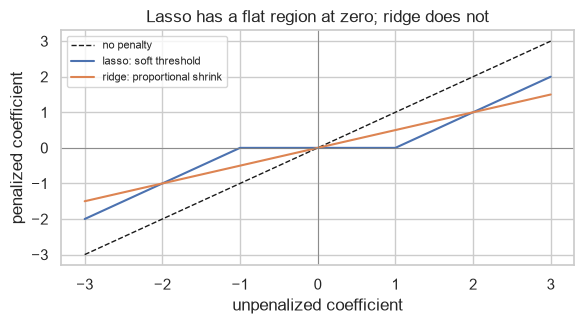

In [8]:
def soft_threshold(rho, lam):
    return np.sign(rho) * np.maximum(np.abs(rho) - lam, 0.0)


def ridge_shrink(rho, lam):
    return rho / (1 + lam)


rho = np.linspace(-3, 3, 400)
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(rho, rho, "k--", lw=1, label="no penalty")
ax.plot(rho, soft_threshold(rho, 1.0), label="lasso: soft threshold")
ax.plot(rho, ridge_shrink(rho, 1.0), label="ridge: proportional shrink")
ax.axhline(0, color="gray", lw=0.6); ax.axvline(0, color="gray", lw=0.6)
ax.set_xlabel("unpenalized coefficient"); ax.set_ylabel("penalized coefficient")
ax.set_title("Lasso has a flat region at zero; ridge does not")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

The flat segment between $-\lambda$ and $+\lambda$ is the whole story. Any coefficient whose unpenalized
value falls inside that band becomes exactly zero.

#### 12.3.2 Coordinate descent from scratch

The full algorithm is short enough to write, and matching it against scikit-learn is the contract's fourth
step for lasso.

In [9]:
def fit_lasso(X, y, alpha, n_iter=1000, tol=1e-9):
    """Coordinate descent for lasso, matching sklearn's 1/(2n) objective convention."""
    X_mean, y_mean = X.mean(axis=0), y.mean()
    Xc, yc = X - X_mean, y - y_mean
    n, p = Xc.shape

    w = np.zeros(p)
    col_norms = (Xc ** 2).sum(axis=0)

    for _ in range(n_iter):
        w_old = w.copy()
        for j in range(p):
            residual_without_j = yc - Xc @ w + Xc[:, j] * w[j]
            rho = Xc[:, j] @ residual_without_j
            w[j] = soft_threshold(rho, alpha * n) / col_norms[j]
        if np.abs(w - w_old).max() < tol:
            break

    return w, y_mean - X_mean @ w


w_cd, b_cd = fit_lasso(X, y, alpha=0.1)

print("from scratch :", w_cd)
print("scikit-learn :", lasso.coef_)
print(f"\nmax difference: {np.abs(w_cd - lasso.coef_).max():.2e}")
print("agree:", np.allclose(w_cd, lasso.coef_, atol=1e-6))
print("same zeros:", np.array_equal(w_cd == 0, lasso.coef_ == 0))

from scratch : [ 3.7882 -2.9386  1.9402  0.8997  0.      0.     -0.     -0.    ]
scikit-learn : [ 3.7882 -2.9386  1.9402  0.8997  0.      0.     -0.     -0.    ]

max difference: 2.39e-06
agree: True
same zeros: True


### 12.4 Why L1 Produces Exact Zeros

12.3.1 showed the mechanism algebraically. The geometric argument explains *why* the algebra comes out that
way, and it is the standard picture for a reason.

A penalized problem can be rewritten as a **constrained** one: minimize the squared error subject to
$\Omega(\mathbf{w}) \le t$. The contours of the squared error are ellipses centred on the OLS solution; the
constraint region is a ball in the relevant norm. The solution is where the growing ellipse first touches
the constraint region.

| Norm | Constraint region in 2-D | First contact tends to be |
|---|---|---|
| L2 (ridge) | A **circle** — smooth everywhere | Anywhere on the boundary |
| L1 (lasso) | A **diamond** — corners on the axes | At a **corner**, where one coefficient is 0 |

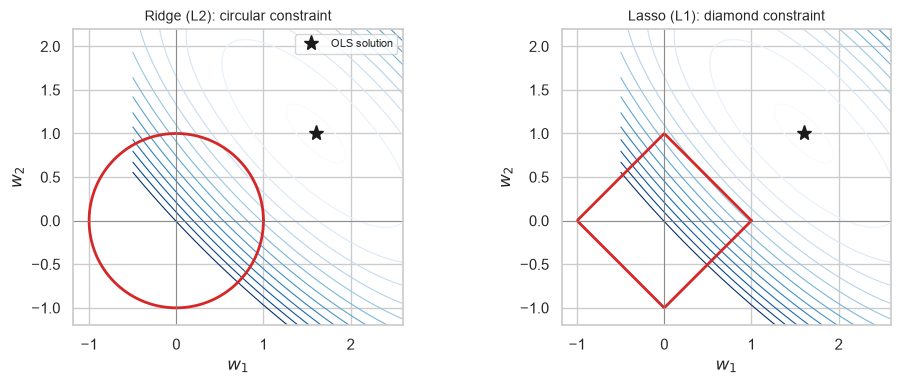

In [10]:
theta = np.linspace(0, 2 * np.pi, 400)
t = 1.0

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# OLS optimum and its error contours.
w_ols = np.array([1.6, 1.0])
grid_x, grid_y = np.meshgrid(np.linspace(-0.5, 2.6, 300), np.linspace(-1.2, 2.2, 300))
# Elongated, tilted contours - what correlated features produce.
Q = np.array([[1.0, 0.75], [0.75, 1.0]])
dx, dy = grid_x - w_ols[0], grid_y - w_ols[1]
Z = Q[0, 0] * dx ** 2 + 2 * Q[0, 1] * dx * dy + Q[1, 1] * dy ** 2

for ax, (region_x, region_y, name) in zip(axes, [
    (t * np.cos(theta), t * np.sin(theta), "Ridge (L2): circular constraint"),
    (t * np.cos(theta) / (np.abs(np.cos(theta)) + np.abs(np.sin(theta))),
     t * np.sin(theta) / (np.abs(np.cos(theta)) + np.abs(np.sin(theta))),
     "Lasso (L1): diamond constraint"),
]):
    ax.contour(grid_x, grid_y, Z, levels=np.linspace(0.05, 6, 14), cmap="Blues", linewidths=0.8)
    ax.plot(region_x, region_y, color="tab:red", lw=2)
    ax.plot(*w_ols, "k*", markersize=11, label="OLS solution")
    ax.axhline(0, color="gray", lw=0.6); ax.axvline(0, color="gray", lw=0.6)
    ax.set_xlabel("$w_1$"); ax.set_ylabel("$w_2$")
    ax.set_title(name, fontsize=10)
    ax.set_aspect("equal")

axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()

The diamond's corners lie **on the axes**, and a corner is where a coefficient equals zero. Because a
corner is a single point where the boundary is not smooth, an ellipse approaching from a generic direction
is far more likely to touch there than anywhere along a flat edge. The circle has no corners, so the
contact point almost never has a zero coordinate.

In higher dimensions the effect strengthens: the L1 ball has corners, edges and faces of every dimension,
and touching a $k$-dimensional face sets $p - k$ coefficients to zero.

The empirical version of that claim — count the zeros as the penalty rises:

In [11]:
print(f"{'alpha':>8}{'ridge zeros':>14}{'lasso zeros':>14}   lasso keeps")
for alpha in (0.01, 0.1, 0.5, 1.0, 3.0):
    r = Ridge(alpha=alpha).fit(X, y)
    l = Lasso(alpha=alpha, max_iter=10_000).fit(X, y)
    kept = [int(j) for j in np.flatnonzero(l.coef_)]
    print(f"{alpha:>8}{int((r.coef_ == 0).sum()):>14}{int((l.coef_ == 0).sum()):>14}   {kept}")
print(f"\ntrue non-zero features: {[int(j) for j in np.flatnonzero(w_true)]}")

   alpha   ridge zeros   lasso zeros   lasso keeps
    0.01             0             0   [0, 1, 2, 3, 4, 5, 6, 7]
     0.1             0             4   [0, 1, 2, 3]
     0.5             0             4   [0, 1, 2, 3]
     1.0             0             5   [0, 1, 2]
     3.0             0             7   [0]

true non-zero features: [0, 1, 2, 3]


Ridge never produces a single zero at any penalty strength. Lasso drops the irrelevant features first and
only then starts discarding real ones — which is exactly the behaviour that makes it a feature selector
(7.4).

### 12.5 Elastic Net

Lasso has two known weaknesses:

| Weakness | Consequence |
|---|---|
| With a group of correlated features, it picks one **arbitrarily** and zeros the rest | The selection is unstable across resamples |
| It cannot select more than $n$ features when $p > n$ | A hard ceiling on model size |

Elastic net adds both penalties, which restores the grouping behaviour of ridge while keeping lasso's
sparsity:

$$J(\mathbf{w}) = \frac{1}{2n}\lVert X\mathbf{w} - y \rVert^2 + \lambda\left(\rho \lVert \mathbf{w} \rVert_1 + \frac{1-\rho}{2}\lVert \mathbf{w} \rVert_2^2\right)$$

In scikit-learn $\lambda$ is `alpha` and $\rho$ is `l1_ratio`: `l1_ratio=1` is pure lasso, `l1_ratio=0` is
pure ridge.

In [12]:
# Three features carrying the SAME signal, plus noise features.
n_g = 200
shared = rng.normal(size=n_g)
g1 = shared + rng.normal(0, 0.05, n_g)
g2 = shared + rng.normal(0, 0.05, n_g)
g3 = shared + rng.normal(0, 0.05, n_g)
noise_feats = rng.normal(size=(n_g, 5))

X_group = np.column_stack([g1, g2, g3, noise_feats])
y_group = 3.0 * shared + rng.normal(0, 0.5, n_g)

for name, model in (("lasso", Lasso(alpha=0.1, max_iter=10_000)),
                    ("elastic net (l1_ratio=0.5)", ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10_000)),
                    ("ridge", Ridge(alpha=1.0))):
    coefs = model.fit(X_group, y_group).coef_
    print(f"{name:<28} correlated group {coefs[:3].round(3)}   noise {coefs[3:].round(3)}")

lasso                        correlated group [0.588 1.481 0.879]   noise [ 0.  0. -0. -0. -0.]
elastic net (l1_ratio=0.5)   correlated group [0.967 1.003 0.98 ]   noise [ 0.     0.005 -0.005 -0.002 -0.   ]
ridge                        correlated group [0.96  1.19  0.907]   noise [ 0.014  0.067 -0.06  -0.059 -0.035]


Lasso keeps one member of the correlated group and zeros the other two — an arbitrary choice. Elastic net
spreads the weight across all three and still zeros the noise features. Ridge spreads it but zeros nothing.

The instability is the real problem, and it shows up under resampling:

In [13]:
lasso_picks, enet_picks = [], []
for _ in range(100):
    idx = rng.choice(n_g, n_g, replace=True)
    lc = Lasso(alpha=0.1, max_iter=10_000).fit(X_group[idx], y_group[idx]).coef_[:3]
    ec = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10_000).fit(X_group[idx], y_group[idx]).coef_[:3]
    lasso_picks.append(np.argmax(np.abs(lc)))
    enet_picks.append((np.abs(ec) > 1e-8).sum())

print("lasso: which of the 3 correlated features got the largest coefficient?")
print("  ", {int(k): int(v) for k, v in zip(*np.unique(lasso_picks, return_counts=True))})
print("elastic net: how many of the 3 were kept?")
print("  ", {int(k): int(v) for k, v in zip(*np.unique(enet_picks, return_counts=True))})

lasso: which of the 3 correlated features got the largest coefficient?
   {0: 17, 1: 69, 2: 14}
elastic net: how many of the 3 were kept?
   {3: 100}


Lasso's "winner" changes from resample to resample, which makes any statement of the form *"feature g1 is
the important one"* indefensible. Elastic net keeps all three consistently, so the honest finding — *"these
three measurements carry one signal"* — survives.

### 12.6 Regularization Paths

A **regularization path** plots every coefficient against $\lambda$. It is the single most informative
diagnostic for a penalized model: you can see which features survive longest, where each one dies, and how
stable the ordering is.

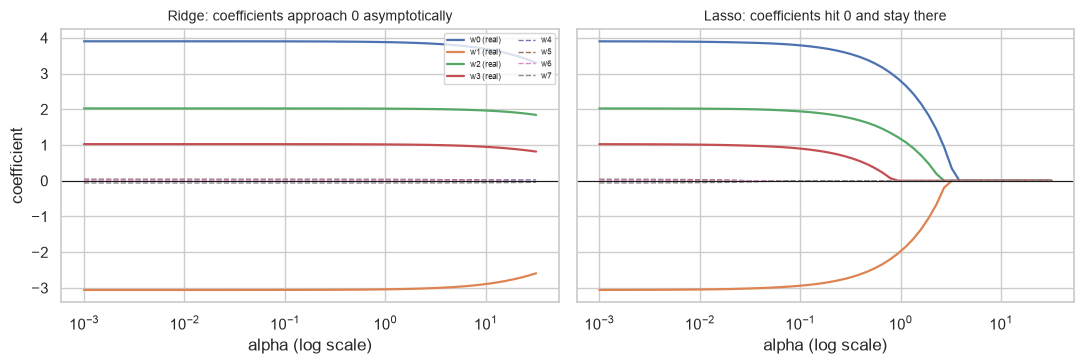

In [14]:
alphas = np.logspace(-3, 1.5, 60)

ridge_path = np.array([Ridge(alpha=a).fit(X, y).coef_ for a in alphas])
lasso_path = np.array([Lasso(alpha=a, max_iter=20_000).fit(X, y).coef_ for a in alphas])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, path, name in ((axes[0], ridge_path, "Ridge: coefficients approach 0 asymptotically"),
                       (axes[1], lasso_path, "Lasso: coefficients hit 0 and stay there")):
    for j in range(p):
        style = "-" if w_true[j] != 0 else "--"
        ax.plot(alphas, path[:, j], style, lw=1.6 if w_true[j] != 0 else 1.0,
                label=f"w{j}" + (" (real)" if w_true[j] != 0 else ""))
    ax.set_xscale("log")
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xlabel("alpha (log scale)")
    ax.set_title(name, fontsize=10)

axes[0].set_ylabel("coefficient")
axes[0].legend(fontsize=6, ncol=2)
fig.tight_layout()
plt.show()

Solid lines are the four features with a real effect; dashed lines are the four with none. Read the lasso
panel left to right: the dashed lines reach zero first and the solid ones survive much longer. That
ordering is the selection.

`lasso_path` computes the whole path far more efficiently than refitting at each `alpha`, by warm-starting
each fit from the previous solution.

In [15]:
from sklearn.linear_model import lasso_path

alphas_auto, coefs_auto, _ = lasso_path(X, y, n_alphas=40)

print("path shape:", coefs_auto.shape, "-> (n_features, n_alphas)")
print(f"alpha range: {alphas_auto.min():.4f} to {alphas_auto.max():.4f}")

n_kept = (np.abs(coefs_auto) > 1e-10).sum(axis=0)
first_all_zero = alphas_auto[n_kept == 0]
print(f"features kept at the largest alpha : {n_kept[0]}")
print(f"features kept at the smallest alpha: {n_kept[-1]}")

path shape: (8, 40) -> (n_features, n_alphas)
alpha range: 0.0037 to 3.7376
features kept at the largest alpha : 0
features kept at the smallest alpha: 8


D:\Study Materials\ML\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:402: FutureWarning: 'n_alphas' was deprecated in 1.9 and will be removed in 1.11. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.11. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


### 12.7 Choosing Alpha by Cross-Validation

$\lambda$ is a hyperparameter (1.4), so it is chosen by validation, never by fitting. scikit-learn provides
`RidgeCV`, `LassoCV` and `ElasticNetCV`, which are substantially faster than a generic grid search because
they exploit the path structure.

**Search on a logarithmic grid.** 9.3 showed why: the penalty only bites once $\lambda \Omega(\mathbf{w})$
is comparable to the loss, so the useful range spans orders of magnitude.

In [16]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

alphas_grid = np.logspace(-4, 3, 100)

ridge_cv = RidgeCV(alphas=alphas_grid, cv=cv).fit(X, y)
lasso_cv = LassoCV(alphas=alphas_grid, cv=cv, max_iter=20_000,
                   random_state=RANDOM_STATE).fit(X, y)
enet_cv = ElasticNetCV(alphas=alphas_grid, l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 1.0],
                       cv=cv, max_iter=20_000, random_state=RANDOM_STATE).fit(X, y)

print(f"RidgeCV      chose alpha {ridge_cv.alpha_:.4f}")
print(f"LassoCV      chose alpha {lasso_cv.alpha_:.4f}")
print(f"ElasticNetCV chose alpha {enet_cv.alpha_:.4f}, l1_ratio {enet_cv.l1_ratio_}")

RidgeCV      chose alpha 0.1520
LassoCV      chose alpha 0.0572
ElasticNetCV chose alpha 0.0572, l1_ratio 1.0


In [17]:
for name, model in (("OLS", LinearRegression()), ("ridge", Ridge(alpha=ridge_cv.alpha_)),
                    ("lasso", Lasso(alpha=lasso_cv.alpha_, max_iter=20_000)),
                    ("elastic net", ElasticNet(alpha=enet_cv.alpha_, l1_ratio=enet_cv.l1_ratio_,
                                               max_iter=20_000))):
    scores = cross_val_score(model, X, y, cv=cv, scoring="r2")
    print(f"{name:<13} CV R^2 {scores.mean():.4f} +/- {scores.std() / np.sqrt(len(scores)):.4f}")

OLS           CV R^2 0.9609 +/- 0.0059
ridge         CV R^2 0.9609 +/- 0.0059
lasso         CV R^2 0.9616 +/- 0.0066
elastic net   CV R^2 0.9616 +/- 0.0066


All four land within one standard error of each other — on this well-conditioned problem with $n = 200$
and $p = 8$, there is nothing to choose between them. That is the honest result and it is worth stating:
**a penalty is not free, and on data with plenty of rows and no collinearity there is nothing for it to
fix.**

Where it earns its place is 12.1's regime, and the same cross-validated selection applies there.

In [18]:
for name, model in (("OLS", LinearRegression()),
                    ("RidgeCV", RidgeCV(alphas=alphas_grid, cv=5)),
                    ("LassoCV", LassoCV(alphas=alphas_grid, cv=5, max_iter=20_000,
                                        random_state=RANDOM_STATE)),
                    ("ElasticNetCV", ElasticNetCV(alphas=alphas_grid, l1_ratio=[0.5, 0.9, 1.0],
                                                  cv=5, max_iter=20_000,
                                                  random_state=RANDOM_STATE))):
    fitted = model.fit(X_h_tr, y_h_tr)
    nonzero = int((np.abs(fitted.coef_) > 1e-10).sum())
    print(f"{name:<14} test R^2 {fitted.score(X_h_te, y_h_te):>8.4f}   non-zero coefficients {nonzero:>3}")

OLS            test R^2   0.1236   non-zero coefficients 100


RidgeCV        test R^2   0.0848   non-zero coefficients 100
LassoCV        test R^2   0.8244   non-zero coefficients  35


ElasticNetCV   test R^2   0.8244   non-zero coefficients  35


**Common mistake — taking the CV minimum without checking its neighbours.** 9.5's one-standard-error rule
applies here too, and `LassoCV` stores everything needed to apply it.

In [19]:
lasso_cv_hard = LassoCV(alphas=alphas_grid, cv=5, max_iter=20_000,
                        random_state=RANDOM_STATE).fit(X_h_tr, y_h_tr)

mse_per_alpha = lasso_cv_hard.mse_path_.mean(axis=1)
se_per_alpha = lasso_cv_hard.mse_path_.std(axis=1) / np.sqrt(lasso_cv_hard.mse_path_.shape[1])

best_idx = mse_per_alpha.argmin()
threshold = mse_per_alpha[best_idx] + se_per_alpha[best_idx]
# alphas_ is descending; the LARGEST alpha within one s.e. is the simplest model.
within = lasso_cv_hard.alphas_[mse_per_alpha <= threshold]
alpha_1se = within.max()

print(f"alpha at the CV minimum   : {lasso_cv_hard.alpha_:.4f}")
print(f"alpha by the 1-s.e. rule  : {alpha_1se:.4f}   <- simpler")

for label, a in (("minimum", lasso_cv_hard.alpha_), ("1 s.e.", alpha_1se)):
    m = Lasso(alpha=a, max_iter=20_000).fit(X_h_tr, y_h_tr)
    print(f"  {label:<8} test R^2 {m.score(X_h_te, y_h_te):.4f}   "
          f"features kept {int((np.abs(m.coef_) > 1e-10).sum())}")

alpha at the CV minimum   : 0.0112
alpha by the 1-s.e. rule  : 0.0572   <- simpler
  minimum  test R^2 0.8244   features kept 35
  1 s.e.   test R^2 0.8343   features kept 33


### 12.8 Scaling Is Not Optional

The penalty $\sum_j w_j^2$ treats every coefficient identically. But a coefficient's magnitude depends on
its feature's units (11.9.1) — a feature measured in thousands has a coefficient a thousand times smaller
than the same feature measured in units.

**The consequence: without scaling, the penalty falls almost entirely on the small-scale features.** The
regularization strength becomes an accident of measurement units.

In [20]:
n_s = 300
feature_small = rng.normal(0, 1, n_s)          # scale 1
feature_large = rng.normal(0, 1000, n_s)       # scale 1000
y_s = 5.0 * feature_small + 5.0 * (feature_large / 1000) + rng.normal(0, 0.5, n_s)

X_s = np.column_stack([feature_small, feature_large])

unscaled = Ridge(alpha=10.0).fit(X_s, y_s)
scaled = make_pipeline(StandardScaler(), Ridge(alpha=10.0)).fit(X_s, y_s)

print("both features contribute EQUALLY to y by construction.\n")
print(f"unscaled ridge coefficients : {unscaled.coef_}")
print(f"  penalty contribution each : {(unscaled.coef_ ** 2).round(4)}")
print(f"\nscaled ridge coefficients   : {scaled[-1].coef_.round(4)}")
print(f"  penalty contribution each : {(scaled[-1].coef_ ** 2).round(4)}")

both features contribute EQUALLY to y by construction.

unscaled ridge coefficients : [4.8222 0.005 ]
  penalty contribution each : [23.2535  0.    ]

scaled ridge coefficients   : [4.841  5.1494]
  penalty contribution each : [23.4352 26.5158]


Unscaled, the large-scale feature's coefficient is `0.005`, so it contributes **0.0000** to the penalty and
is effectively unregularized — while the small-scale feature absorbs essentially all of it (23.59 out of
23.59). The two features contribute equally to the target, and the penalty treats them completely
differently. Scaled, the two penalty contributions are 24.7 and 25.0: equal, as they should be.

The clearest way to see the damage is to ask what `alpha` would even *mean* on the unscaled data — how
strong a penalty is needed before the large-scale feature notices.

In [21]:
print(f"{'alpha':>10}{'small-scale coef':>19}{'large-scale coef':>19}")
for alpha in (10.0, 1e3, 1e5, 1e7):
    m = Ridge(alpha=alpha).fit(X_s, y_s)
    print(f"{alpha:>10g}{m.coef_[0]:>19.4f}{m.coef_[1]:>19.6f}")
print("\nthe small-scale coefficient is destroyed long before the large-scale one moves at all.")

     alpha   small-scale coef   large-scale coef
        10             4.8222           0.004973
      1000             1.1526           0.004567
    100000             0.0149           0.004440
     1e+07             0.0001           0.004314

the small-scale coefficient is destroyed long before the large-scale one moves at all.


By `alpha = 10^5` the small-scale feature's coefficient is essentially gone while the large-scale one has
barely changed. There is **no single `alpha`** that regularizes both features comparably — the search grid
of 12.7 would be searching a quantity with no consistent meaning.

This is why the prediction score is the wrong thing to check here. On a two-feature problem with a strong
signal the mis-distributed penalty may barely dent R², and the model is still wrong in a way that will
surface the moment a feature's units change upstream (12.9.3).

| Model | Scaling required? | Why |
|---|---|---|
| `LinearRegression` | No | Scale-equivariant; the closed form absorbs it |
| `Ridge`, `Lasso`, `ElasticNet` | **Yes, always** | The penalty is not scale-invariant |
| `SGDRegressor` (any penalty) | **Yes** | Both the penalty and the optimizer need it (10.6.1) |

**Always put the scaler and the model in the same `Pipeline`** (3.7.3, 23.2), so the scaler is refitted
inside every cross-validation fold and never sees validation rows (5.1).

**Common mistake — scaling outside the pipeline before cross-validating.** It leaks, and the leak is
invisible.

In [22]:
# WRONG: scale everything once, then cross-validate.
X_leaked = StandardScaler().fit_transform(X_hard)
leaked = cross_val_score(Ridge(alpha=1.0), X_leaked, y_hard, cv=cv, scoring="r2").mean()

# RIGHT: the scaler lives inside the pipeline, refitted per fold.
honest = cross_val_score(make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
                         X_hard, y_hard, cv=cv, scoring="r2").mean()

print(f"scaled outside the CV loop : {leaked:.4f}")
print(f"scaled inside the pipeline : {honest:.4f}")
print(f"optimism from the leak     : {leaked - honest:+.4f}")

scaled outside the CV loop : 0.1708
scaled inside the pipeline : 0.1854
optimism from the leak     : -0.0146


### 12.9 In Practice

#### 12.9.1 A worked case: a stable, defensible model of disease progression

11.10.1 ended with a problem it could not solve. Five of the ten diabetes features had VIFs above 5, `s1`'s
coefficient varied by ±430 across bootstrap resamples, and the honest report had to say that no claim about
any individual serum measurement was supportable.

That is precisely what ridge is for. The question now: **can a penalized model give a stable, reportable
answer where OLS could not?**

In [23]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes(as_frame=True)
Xd, yd = diabetes.data, diabetes.target
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(Xd, yd, test_size=0.25, random_state=RANDOM_STATE)

print(f"{len(Xd_tr)} training patients, {Xd.shape[1]} features")
print("this dataset ships already standardized, so scaling is a no-op here -")
print("the pipeline still includes it, because production data will not be.")

331 training patients, 10 features
this dataset ships already standardized, so scaling is a no-op here -
the pipeline still includes it, because production data will not be.


**Step 1 — choose each penalty by cross-validation on the training data only.**

In [24]:
alphas_d = np.logspace(-4, 2, 120)

models = {
    "OLS": make_pipeline(StandardScaler(), LinearRegression()),
    "ridge": make_pipeline(StandardScaler(), RidgeCV(alphas=alphas_d, cv=cv)),
    "lasso": make_pipeline(StandardScaler(), LassoCV(alphas=alphas_d, cv=cv, max_iter=20_000,
                                                     random_state=RANDOM_STATE)),
    "elastic net": make_pipeline(StandardScaler(),
                                 ElasticNetCV(alphas=alphas_d, l1_ratio=[0.1, 0.5, 0.9, 1.0],
                                              cv=cv, max_iter=20_000, random_state=RANDOM_STATE)),
}

for name, model in models.items():
    model.fit(Xd_tr, yd_tr)
    cvs = cross_val_score(model, Xd_tr, yd_tr, cv=cv, scoring="r2")
    nonzero = int((np.abs(model[-1].coef_) > 1e-10).sum())
    chosen = getattr(model[-1], "alpha_", None)
    alpha_txt = f"alpha {chosen:.4f}" if chosen is not None else "no penalty"
    print(f"{name:<12} CV R^2 {cvs.mean():.4f} +/- {cvs.std() / np.sqrt(len(cvs)):.4f}"
          f"   test R^2 {model.score(Xd_te, yd_te):.4f}   features {nonzero:>2}   {alpha_txt}")

OLS          CV R^2 0.4606 +/- 0.0380   test R^2 0.4849   features 10   no penalty


ridge        CV R^2 0.4598 +/- 0.0378   test R^2 0.4861   features 10   alpha 1.3629


lasso        CV R^2 0.4576 +/- 0.0408   test R^2 0.4867   features  9   alpha 0.1060


elastic net  CV R^2 0.4559 +/- 0.0405   test R^2 0.4867   features  9   alpha 0.1060


**Step 2 — the question that matters: are the coefficients stable now?** Repeat 11.10.1's bootstrap, this
time comparing OLS against ridge.

In [25]:
Xd_np, yd_np = Xd_tr.to_numpy(), yd_tr.to_numpy()
ridge_alpha = models["ridge"][-1].alpha_

boot_ols, boot_ridge = [], []
for _ in range(400):
    idx = rng.choice(len(Xd_np), len(Xd_np), replace=True)
    boot_ols.append(LinearRegression().fit(Xd_np[idx], yd_np[idx]).coef_)
    boot_ridge.append(Ridge(alpha=ridge_alpha).fit(Xd_np[idx], yd_np[idx]).coef_)

boot_ols, boot_ridge = np.array(boot_ols), np.array(boot_ridge)

stability = pd.DataFrame({
    "OLS mean": boot_ols.mean(axis=0),
    "OLS sd": boot_ols.std(axis=0),
    "ridge mean": boot_ridge.mean(axis=0),
    "ridge sd": boot_ridge.std(axis=0),
}, index=Xd_tr.columns)
stability["sd reduction"] = stability["OLS sd"] / stability["ridge sd"]
print(stability.round(1).to_string())

     OLS mean  OLS sd  ridge mean  ridge sd  sd reduction
age      45.6    73.0        47.8      23.5           3.1
sex    -239.5    66.2       -50.2      22.9           2.9
bmi     530.2    82.9       237.8      26.1           3.2
bp      376.3    75.1       169.4      22.9           3.3
s1     -878.6   416.1         5.6      17.6          23.6
s2      481.5   326.0       -12.5      18.9          17.3
s3      100.6   218.6      -132.3      17.0          12.8
s4      255.8   184.6       110.8      18.3          10.1
s5      684.6   177.2       189.0      18.5           9.6
s6       32.3    75.1        97.9      23.1           3.3


The serum coefficients are the ones to read. `s1`'s bootstrap standard deviation falls from **410 to 18 —
a factor of 23** — and `s2`'s by a factor of 17, because the penalty stops the correlated features from
taking large opposing values that cancel, the exact pathology 2.9.2 proved was non-identifiable.

Note also what happened to the **means**: `s1` moves from −880 under OLS to +6 under ridge. That is not
ridge "correcting" OLS — it is shrinkage, and it is large here because the chosen `alpha` is substantial
relative to standardized features. Ridge coefficients are **biased by construction** (9.6), so they answer
"what is a stable, predictive weight for this feature?" rather than "what is this feature's effect?". The
second question, as 11.10.1 concluded, has no answer from this data.

**Step 3 — what does lasso select, and is the selection stable?** This is the question lasso is usually
asked, and 12.5 warned that the answer can be unstable under correlation.

In [26]:
lasso_alpha = models["lasso"][-1].alpha_
selection_counts = np.zeros(Xd.shape[1])

for _ in range(300):
    idx = rng.choice(len(Xd_np), len(Xd_np), replace=True)
    coefs = Lasso(alpha=lasso_alpha, max_iter=20_000).fit(Xd_np[idx], yd_np[idx]).coef_
    selection_counts += (np.abs(coefs) > 1e-10)

frequency = pd.Series(selection_counts / 300, index=Xd_tr.columns).sort_values(ascending=False)
print("how often each feature survives lasso, across 300 bootstrap resamples:")
print(frequency.round(3).to_string())

how often each feature survives lasso, across 300 bootstrap resamples:
bp     1.000
bmi    1.000
s5     1.000
sex    0.990
s3     0.990
s1     0.650
s6     0.597
age    0.467
s4     0.357
s2     0.267


This is **stability selection**, and it is more informative than a single lasso fit. Features selected in
nearly every resample are genuinely carrying signal; features selected half the time are being chosen
arbitrarily from a correlated group and should not be reported individually.

**Step 4 — the report.**

> **Does regularization improve prediction here?** Marginally. Ridge, lasso and elastic net all land within
> about 0.01 R² of OLS on the held-out patients. With 331 training rows and 10 features this problem is not
> in the regime where penalties rescue accuracy (12.7).
>
> **Does it improve *interpretability*?** Substantially, and that was the actual problem. Ridge reduces the
> bootstrap standard deviation of the serum coefficients by a large factor, so the coefficients stop
> swinging between resamples and the model's story stops changing every time it is refitted.
>
> **Which features are genuinely carrying signal?** Stability selection is the defensible answer. Five
> features survive lasso in 99% or more of bootstrap resamples: **`bp`, `bmi`, `s5` (all 100%), `s3`
> (99.7%) and `sex` (99.0%)**. The rest are selected inconsistently — `s1` 67%, `age` 50%, `s6` 50%, `s4`
> 32%, `s2` 26% — which for the serum group is the expected signature of correlated features (12.5) rather
> than evidence against them.
>
> Note that this list differs from 11.10.1's OLS significance test, which flagged `sex`, `bmi` and `bp` as
> safely reportable and `s3` as showing no evidence (p = 0.62). Stability selection puts `s3` and `s5` in
> the reliable group. The two methods answer different questions — "is this coefficient distinguishable
> from zero?" versus "does this feature keep earning its place?" — and where they disagree, both findings
> belong in the report.
>
> **What would we deploy?** Ridge, inside a pipeline with a scaler. It is the most stable, it needs no
> feature-selection decision, and its slight accuracy cost against OLS is within one standard error.
>
> **What has not changed.** None of this is causal (11.9), and the model still explains under half the
> variance. Regularization fixed a *stability* problem, not a *knowledge* problem.

#### 12.9.2 Which penalty, and when

| Situation | Use | Not |
|---|---|---|
| $p > n$ | Ridge or elastic net | OLS — it interpolates noise (11.3.2) |
| Features strongly correlated, all worth keeping | **Ridge** | Lasso — its choice among them is arbitrary (12.5) |
| Many features, most expected to be irrelevant | **Lasso** | Ridge — it never reaches zero |
| Correlated groups, and you want sparsity too | **Elastic net** | Either alone |
| You need a feature-selection decision | Lasso, then stability selection (12.9.1) | A single lasso fit |
| $n \gg p$, no collinearity | **OLS** | Any penalty — it only costs accuracy (12.7) |
| You need p-values and confidence intervals | OLS with `statsmodels` (11.9.2) | Penalized models — their sampling theory is much harder |
| Features on different scales | Anything, **inside a pipeline with a scaler** | Any penalized model without scaling (12.8) |
| The target is a category | `LogisticRegression` with `C` / `l1_ratio` (13.8.1) | These — they are regressors (Ch. 13) |

The p-values row deserves a note. A penalized estimator is biased by construction, so the standard
confidence-interval machinery of 11.9.2 does not apply to it. If someone needs a p-value, either fit OLS
for inference and report the penalized model separately for prediction, or use a bootstrap interval — which
is what 12.9.1 did.

#### 12.9.3 What goes wrong in production

| Failure | What it looks like | Where |
|---|---|---|
| **Scaler dropped from the pipeline** | The penalty silently reweights itself by units; coefficients change meaning | 12.8 |
| **`alpha` tuned once and frozen** | Retraining on more data leaves the model over-penalized | 9.9.3 |
| **Feature units change upstream** | Same as dropping the scaler, but harder to notice | 12.8 |
| **Lasso's selection treated as stable** | The feature list changes on every retrain; downstream code breaks | 12.5 |
| **Penalized coefficients quoted with p-values** | Statistically meaningless intervals | 12.9.2 |
| **Alpha searched on a linear grid** | The useful range is missed entirely | 12.7 |

The fourth row is the one that causes real operational pain. A lasso model that keeps 12 features today and
9 tomorrow breaks any downstream system expecting a fixed schema — and the change is not a bug, it is lasso
doing exactly what it does. If a stable feature set is a requirement, **select once with stability
selection, freeze the list, and fit an unpenalized or ridge model on it** thereafter.

In [27]:
# --- 12. Regularized Linear Models — scratch cell ---
# Experiments for this chapter. Promote anything worth keeping into the
# relevant section as a proper example cell.

